<a href="https://colab.research.google.com/github/xbadiam/Energy_consumption_steel_industry/blob/main/notebooks/Energy_consumption_steel_industry_LSMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Energy consumption of the steel industry**



## 1. Context

This company produces several types of coils, steel plates, and iron plates. The information on electricity consumption is held in a cloud-based system. The information on energy consumption of the industry is stored on the website of the Korea Electric Power Corporation (pccs.kepco.go.kr), and the perspectives on daily, monthly, and annual data are calculated and shown.

### 1.1. Attribute Information:

* Date Continuous-time data taken on the first of the month
* Usage_kWh Industry Energy Consumption Continuous kWh
* Lagging Current reactive power Continuous kVarh
* Leading Current reactive power Continuous kVarh
* CO2 Continuous ppm
* NSM Number of Seconds from midnight Continuous S
* Week status Categorical (Weekend (0) or a Weekday(1))
* Day of week Categorical Sunday, Monday : Saturday
* Load Type Categorical Light Load, Medium Load, Maximum Load

### 1.2. Acknowledgements

This dataset is sourced from the UCI Machine Learning Repository

### 1.3. Inspiration
Which times of the year is the most energy consumed?
What patterns can we identify in energy usage?

1.2 Modelos univariados-unistep
El modelo univariado-unistep es el tipo de predicción más simple que podemos realizar usando Redes LSTM.

En este tipo de configuración usamos una variable a la entrada del modelo y tendremos una variable de salida y la predicción se realiza tan sólo un instante de tiempo a futuro dentro de la serie. Además, generalmente la variable de entrada es la misma variable a predecir.

Por ejemplo, si volvemos al caso de la temperatura, podríamos desarrollar un modelo que acepte un registro histórico de 24 horas de la temperatura y que aprenda a predecir el comportamiento que tendrá esa misma variable temperatura en la siguiente hora.

In [1]:
!rm -rf /content/Energy_consumption_steel_industry

! git clone https://github.com/xbadiam/Energy_consumption_steel_industry.git

Cloning into 'Energy_consumption_steel_industry'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 172 (delta 75), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 1.59 MiB | 4.54 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [2]:
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.1 MB/s eta 0:00:00


## 2. Imports

In [3]:
# Data processing
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Forecasting and modeling
# ==============================================================================
import tensorflow as tf
import keras
from keras import layers
from keras import ops
import keras_tuner as kt
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
#from tensorflow.keras.optimizers import RMSprop

## 3. Functions

In [4]:
# Función para generar las particiones preservando las características
# de la serie de tiempo

def train_val_test_split(serie, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
  # Definir número de datos en cada subserie
  data_number = serie.shape[0]
  n_train = int(tr_size* data_number)  # Número de datos de entrenamiento
  n_val = int(vl_size* data_number)    # Número de datos de validación
  n_test = data_number - n_train - n_val # Número de datos de prueba

  # Realizar partición
  train = serie[0:n_train]
  val = serie[n_train:n_train + n_val]
  test = serie[n_train + n_val:]

  return train, val, test

def create_dataset_supervised(array, input_length, output_length):
  '''Permite crear un dataset con las entradas (X) y salidas (Y)
  requeridas por la Red LSTM.

  Parámetros:
    - array: numpy de tamaño N x features (N: cantidad de datos,
      f: cantidad de features).
    - input_length: instantes de tiempo consecutivos de la(s) serie(s) de tiempo
      usados para alimentar el modelo.
    - output_length: instantes de tiempo a pronosticar (salida del modelo)
  '''

  # Inicialización
  X, Y = [], []    # Listados con los datos de entrada y salida del modelo
  shape = array.shape
  if len(shape) == 1: # Si tenemos sólo una serie (univariado)
    rows, cols = array.shape[0], 1
    array = array.reshape(rows, cols)
  else: # Multivariado
     rows, cols = array.shape

  # Generar los arreglos
  for i in range(rows - input_length - output_length):
    X.append(array[i:i + input_length, 0:cols])
    Y.append(array[i + input_length:i + input_length + output_length, -1].reshape(output_length, 1))

  # Convertir listas a arreglos de NumPy
  X = np.array(X)
  Y = np.array(Y)

  return X, Y


def scale_data(data_input):
  '''Escala el dataset en el rango de -1 a 1.
  Entradas:
    data_input: diccionario con los dataset de entrada y salida del modelo
    (data_input = {'x_train':x_train, 'y_train':y_train,
                   'x_val':x_val, 'y_val':y_val,
                    'y_test':y_test})

  Retorna:
    - data_scaled: diccionario con los datasets de entrada y salida escalados
      (tiene la misma estructura del diccionario de entrada)
    - scaler: el escalador usado (requerido para las predicciones)
    '''
  # El índice [2] se refiere al tercer eje del tensor (samples, timesteps, features)
  nfeats = data_input['x_train'].shape[2]

  # Generar listado con "scalers" (en este caso, por ser sólo 1 característica
  # se tendrá sólo 1 escalador)
  scalers = [MinMaxScaler(feature_range=(-1,1)) for _ in range(nfeats)]

  # Esto crea nuevas matrices del mismo tamaño que los datos originales,
  # pero vacías, donde se guardarán los datos transformados.
  x_train_scaled = np.zeros_like(data_input['x_train'])
  x_val_scaled = np.zeros_like(data_input['x_val'])
  x_test_scaled = np.zeros_like(data_input['x_test'])
  y_train_scaled = np.zeros_like(data_input['y_train'])
  y_val_scaled = np.zeros_like(data_input['y_val'])
  y_test_scaled = np.zeros_like(data_input['y_test'])

  # Escalamiento: se usarán los min/max del set de entrenamiento para
  # escalar la totalidad de los datasets

  # Escalamiento Xs: en este caso debemos garantizar que cada dato de entrada
  # a fit_transform o transform debe ser de tamaño nsamples x nfeatures
  # (en este caso 24x13)
  for i in range(nfeats):
    x_train_scaled[:,:,i] = scalers[i].fit_transform(x_train[:,:,i])
    x_val_scaled[:,:,i] = scalers[i].transform(x_val[:,:,i])
    x_test_scaled[:,:,i] = scalers[i].transform(x_test[:,:,i])

  # Escalamiento Ys
  y_train_scaled[:,:,0] = scalers[-1].fit_transform(y_train[:, :,0])
  y_val_scaled[:,:,0] = scalers[-1].transform(y_val[:, :,0])
  y_test_scaled[:,:,0] = scalers[-1].transform(y_test[:, :,0])

  # Conformar diccionario de salida
  data_scaled = {
      'x_train_scaled': x_train_scaled, 'y_train_scaled': y_train_scaled,
      'x_val_scaled': x_val_scaled, 'y_val_scaled': y_val_scaled,
      'x_test_scaled': x_test_scaled, 'y_test_scaled': y_test_scaled,
  }

  return data_scaled, scalers[0]


## 4. Load data

In [5]:
data = pd.read_csv('/content/Energy_consumption_steel_industry/inputs/Steel_industry_data.csv')

In [6]:
data.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


## 5. Dataset partitioning

In [7]:
train, val, test = train_val_test_split(data['Usage_kWh'])

print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (28032,)
Tamaño set de validación: (3504,)
Tamaño set de prueba: (3504,)


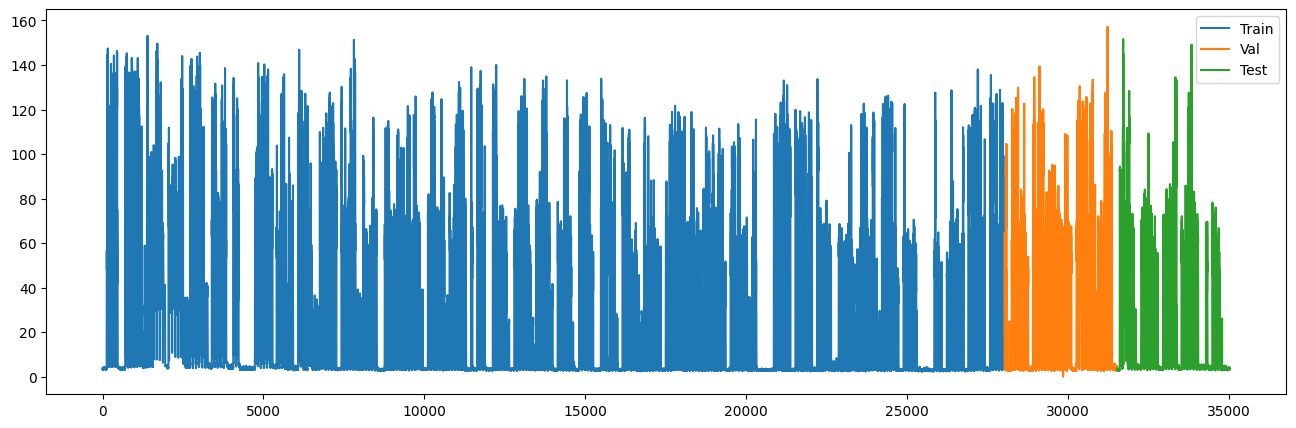

In [8]:
# Dibujemos los subsets
fig, ax = plt.subplots(figsize = (16,5))
ax.plot(train, label='Train')
ax.plot(val, label='Val')
ax.plot(test, label='Test')
plt.legend();

Observemos que por ser un modelo univariado sólo estamos preservando la variable temperatura (y que incluso hemos eliminado la información de fecha y hora de cada registro).

In [9]:
# Crear los datasets de entrenamiento, prueba y validación y verificar sus tamaños
INPUT_LENGTH = 96    # Posteriormente afinaremos este hiperparámetro
OUTPUT_LENGTH = 1    # Modelo uni-step

x_train, y_train = create_dataset_supervised(train.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_val, y_val = create_dataset_supervised(val.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_test, y_test = create_dataset_supervised(test.values, INPUT_LENGTH, OUTPUT_LENGTH)

# Imprimir información en pantalla
print('Tamaños entrada (BATCHES x INPUT_LENGTH x FEATURES) y de salida (BATCHES x OUTPUT_LENGTH x FEATURES)')
print(f'Set de entrenamiento - x_train: {x_train.shape}, y_tr: {y_train.shape}')
print(f'Set de validación - x_val: {x_val.shape}, y_vl: {y_val.shape}')
print(f'Set de prueba - x_test: {x_test.shape}, y_ts: {y_test.shape}')

Tamaños entrada (BATCHES x INPUT_LENGTH x FEATURES) y de salida (BATCHES x OUTPUT_LENGTH x FEATURES)
Set de entrenamiento - x_train: (27935, 96, 1), y_tr: (27935, 1, 1)
Set de validación - x_val: (3407, 96, 1), y_vl: (3407, 1, 1)
Set de prueba - x_test: (3407, 96, 1), y_ts: (3407, 1, 1)


## Data scaled

In [10]:
# Create input dictionary
data_in = {
    'x_train': x_train, 'y_train': y_train,
    'x_val': x_val, 'y_val': y_val,
    'x_test': x_test, 'y_test': y_test
}

In [11]:
data_scaled, scaler = scale_data(data_in)

In [12]:
# Extraer subsets escalados
x_train_scaled, y_train_scaled = data_scaled['x_train_scaled'], data_scaled['y_train_scaled']
x_val_scaled, y_val_scaled = data_scaled['x_val_scaled'], data_scaled['y_val_scaled']
x_test_scaled, y_test_scaled = data_scaled['x_test_scaled'], data_scaled['y_test_scaled']

In [13]:
#Verificación
print(f'Min x_train/x_val/x_test sin escalamiento: {x_train.min()}/{x_val.min()}/{x_test.min()}')
print(f'Min x_train/x_val/x_test con escalamiento: {x_train_scaled.min()}/{x_val_scaled.min()}/{x_test_scaled.min()}')

print(f'\nMin y_train/y_val/y_test sin escalamiento: {y_train.min()}/{y_val.min()}/{y_test.min()}')
print(f'Min y_train/y_val/y_test con escalamiento: {y_train_scaled.min()}/{y_val_scaled.min()}/{y_test_scaled.min()}')

print(f'\nMax x_train/x_val/x_test sin escalamiento: {x_train.max()}/{x_val.max()}/{x_test.max()}')
print(f'Max x_train/x_val/x_test con escalamiento: {x_train_scaled.max()}/{x_val_scaled.max()}/{x_test_scaled.max()}')

print(f'\nMax y_train/y_val/y_test sin escalamiento: {y_train.max()}/{y_val.max()}/{y_test.max()}')
print(f'Max y_train/y_val/y_test con escalamiento: {y_train_scaled.max()}/{y_val_scaled.max()}/{y_test_scaled.max()}')


Min x_train/x_val/x_test sin escalamiento: 2.45/0.0/2.74
Min x_train/x_val/x_test con escalamiento: -1.0/-1.0325170880615835/-0.996151038555976

Min y_train/y_val/y_test sin escalamiento: 2.45/0.0/2.88
Min y_train/y_val/y_test con escalamiento: -1.0/-1.0325170880615835/-0.9942929192381712

Max x_train/x_val/x_test sin escalamiento: 153.14/157.18/151.67
Max x_train/x_val/x_test con escalamiento: 0.9999999999999998/1.053620014599509/0.9804897471630498

Max y_train/y_val/y_test sin escalamiento: 153.14/157.18/151.67
Max y_train/y_val/y_test con escalamiento: 0.9999999999999998/1.053620014599509/0.9804897471630498


## 6. Modelado

- Entradas: arreglos *x* (batches x input-length  x features = batches x 24 x 1)
- Salidas: arreglos *y* (batches x output-length x features = batches x 1 x 1)

Usaremos la raíz cuadrada del error cuadrático medio (o RMSE por sus siglas en Inglés: *root mean square error*) como pérdida para entrenar el modelo:

$RMSE = \sqrt{\frac{\sum_i (y_i-\hat{y_i})^2}{N}}$

donde:
- $y$: Consumo continuo de energía industrial
- $\hat{y}$: Consumo continuo de energía industrial predicha
- $N$: cantidad de predicciones

In [14]:
# Ajustar parámetros para reproducibilidad del entrenamiento
tf.random.set_seed(123)
tf.config.experimental.enable_op_determinism()

# El modelo
N_UNITS = 128 # Tamaño del estado oculto (h) y de la celda de memoria (c)
INPUT_SHAPE = (x_train_scaled.shape[1], x_train_scaled.shape[2]) # 24 (horas) x 1 (feature)

In [15]:
modelo = keras.Sequential()
modelo.add(layers.Input(shape=INPUT_SHAPE))
modelo.add(layers.LSTM(N_UNITS))
modelo.add(layers.Dense(OUTPUT_LENGTH, activation='linear')) # activation = 'linear' pues queremos pronosticar (regresión) escala -1 a 1.

In [16]:
# Pérdida: se usará el RMSE (root mean squared error) para el entrenamiento
# pues permite tener errores en las mismas unidades de la temperatura
def root_mean_squared_error(y_true, y_pred):
    rmse = tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred - y_true)))
    return rmse

In [17]:
# Obtimizador para minimizar la perdida
optimizador = tf.keras.optimizers.RMSprop(learning_rate = 5e-5)
modelo.compile(optimizer = optimizador,
               loss = root_mean_squared_error)

# Entrenamiento (aproximadamente 1 min usando GPU)
EPOCHS = 81 # Hiperparámetro
BATCH_SIZE = 256 # Hiperparámetro
historia = modelo.fit(
    x = x_train_scaled,
    y = y_train_scaled,
    batch_size = BATCH_SIZE,
    epochs = EPOCHS,
    validation_data = (x_val_scaled, y_val_scaled),
    verbose=2 # Imprime en pantalla la evolución del entrenamiento
)

Epoch 1/81
110/110 - 8s - 75ms/step - loss: 0.5001 - val_loss: 0.3513
Epoch 2/81
110/110 - 5s - 44ms/step - loss: 0.3189 - val_loss: 0.3146
Epoch 3/81
110/110 - 1s - 10ms/step - loss: 0.2927 - val_loss: 0.2951
Epoch 4/81
110/110 - 1s - 10ms/step - loss: 0.2771 - val_loss: 0.2809
Epoch 5/81
110/110 - 1s - 10ms/step - loss: 0.2651 - val_loss: 0.2690
Epoch 6/81
110/110 - 1s - 10ms/step - loss: 0.2548 - val_loss: 0.2586
Epoch 7/81
110/110 - 1s - 11ms/step - loss: 0.2459 - val_loss: 0.2491
Epoch 8/81
110/110 - 1s - 11ms/step - loss: 0.2377 - val_loss: 0.2403
Epoch 9/81
110/110 - 1s - 10ms/step - loss: 0.2302 - val_loss: 0.2322
Epoch 10/81
110/110 - 1s - 10ms/step - loss: 0.2235 - val_loss: 0.2248
Epoch 11/81
110/110 - 1s - 10ms/step - loss: 0.2177 - val_loss: 0.2187
Epoch 12/81
110/110 - 1s - 10ms/step - loss: 0.2128 - val_loss: 0.2140
Epoch 13/81
110/110 - 1s - 10ms/step - loss: 0.2087 - val_loss: 0.2102
Epoch 14/81
110/110 - 1s - 10ms/step - loss: 0.2051 - val_loss: 0.2067
Epoch 15/81
110

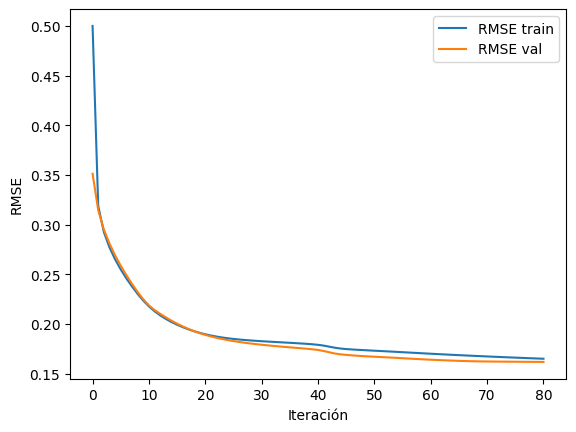

In [18]:
# Graficar curvas de entrenamiento y validación
 # para verificar que no existe overfitting
plt.plot(historia.history['loss'], label='RMSE train')
plt.plot(historia.history['val_loss'], label='RMSE val')
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.legend();

Ambas curvas disminuyen de forma constante durante el entrenamiento. No hay separación significativa entre la curva azul (train) y la naranja (val).

El RMSE en validación sigue bajando al mismo ritmo o incluso un poco más que el de entrenamiento.

El modelo no muestra síntomas de sobreentrenamiento. Ambas curvas convergen hacia un valor bajo (~0.15 de RMSE) y No hay separación entre ellas. Esto sugiere que el modelo generaliza bien y el ajuste es correcto.

## 7. FIne tuning de parámetros

Para realizar una elección de parámetros que optimize los resultados utilizaremos la librería <code>keras-tuner</code>.

<p>Los parámetros que eligiremos para el ajuste son:</p>
  <ul>
    <li><strong>Unidades de la primera capa</strong>. Variarán entre 16 y 64 con steps de 16.</li>
    <li>Añadiremos <strong>dropout en la segunda capa</strong> y los valores serán: 0, 0.1, 0.25 y 0.7 </li>
    <li><strong>Learning rate</strong> que podrá tomar los siguientes valores: 1e-2, 5e-3 y 1e-3</li>
  </ul>
<p>Finalmente, usaremos el método de <code>Hyperband</code> cuyo objetivo será optimizar la <i>accuracy</i> de validación.</p>
</div>

In [19]:
def model_builder(hp):
  model = keras.Sequential(name='model')

  # Tune the number of units in the first Dense layer
  # Choose an optimal value between 32-512
  hp_units = hp.Int('units', min_value=16, max_value=126, step=16)
  model.add(layers.LSTM(units=hp_units, input_shape = INPUT_SHAPE, return_sequences = True))
  hp_dropout = hp.Choice('dropout', values=[0., 0.1, 0.25, 0.7])
  model.add(layers.Dense(OUTPUT_LENGTH, 'linear'))

  # Use 'mean_squared_error' as the loss and keep the custom RMSE as a metric
  loss = root_mean_squared_error

  # Tune the learning rate for the optimizer
  # Choose an optimal value from 0.01, 0.001, or 0.0001
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 5e-5])
  optimizer = tf.keras.optimizers.RMSprop(learning_rate=hp_learning_rate)
  metric1 = root_mean_squared_error

  model.compile(optimizer = optimizer,
                loss = loss,
                metrics = [metric1])

  return model

In [20]:
tuner = kt.Hyperband(model_builder,
                     objective='val_root_mean_squared_error',
                     max_epochs=100,
                     factor=3,
                     overwrite=True,
                     #directory=home,
                     project_name='GRU_best_model')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
#callbacks
tuner.search(x_train, y_train, epochs=2, validation_data=(x_val, y_val))
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 92 Complete [00h 00m 14s]
val_root_mean_squared_error: 19.824975967407227

Best val_root_mean_squared_error So Far: 19.427730560302734
Total elapsed time: 00h 20m 59s


In [22]:
best_units = best_hps.get('units')
best_dropout = best_hps.get('dropout')
best_learning_rate = best_hps.get('learning_rate')

print('best_units:', best_units)
print('best_dropout:', best_dropout)
print('best_learning_rate:', best_learning_rate)

best_units: 64
best_dropout: 0.7
best_learning_rate: 0.01
